# Project DEFI: Decision-Feedback Equalizer Implementation

**Objective:** Use a DFE to mitigate ISI in a simple digital channel.

## 1. Import Required Libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt
#from pysdr import digital, spectrum
from scipy.signal import correlate


# Custom utils
import sys
sys.path.append('../src')
from utils import *

## 2. Simulate ISI Channel
- Create a simple 2-tap channel.
- Generate BPSK symbols and pass them through the channel.

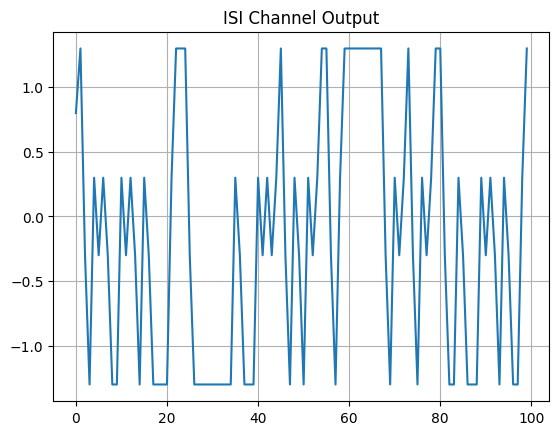

In [12]:
# TODO: ISI channel simulation
num_symbols = 1000

# create a stream of 1000 symbols [-1,1]
bits = np.random.randint(0, 2, num_symbols)
symbols = 2*bits - 1

# 2-tap channel: h[n] = [0.8, 0.5]
isi_channel = np.array([0.8, 0.5])

# discrete convolution of the symbol stream with the transfer function of the channel.
received = np.convolve(symbols, isi_channel, mode='same')


plt.figure()
plt.plot(received[:100])
plt.title('ISI Channel Output')
plt.grid()
plt.show()


Even though DFE does not mitigate noise, adding noise provides a more realistic scenario of the channel.

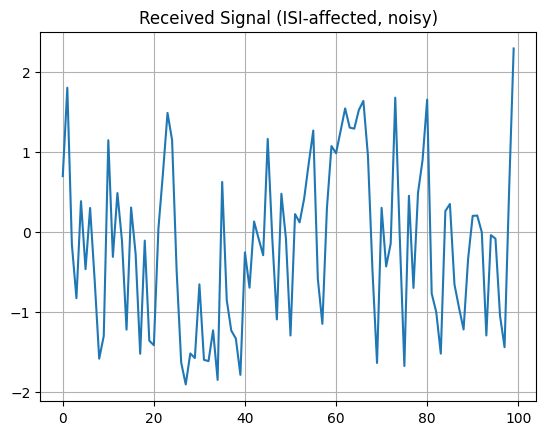

In [13]:
# Add additive white gaussian noise (AWGN)
#Add AWGN
SNR_dB = 10
received_noisy = add_awgn_noise(received, SNR_dB)

plt.plot(received_noisy[:100])
plt.title("Received Signal (ISI-affected, noisy)")
plt.grid()
plt.show()

## 3. Visualize ISI Effects (Eye Diagram)

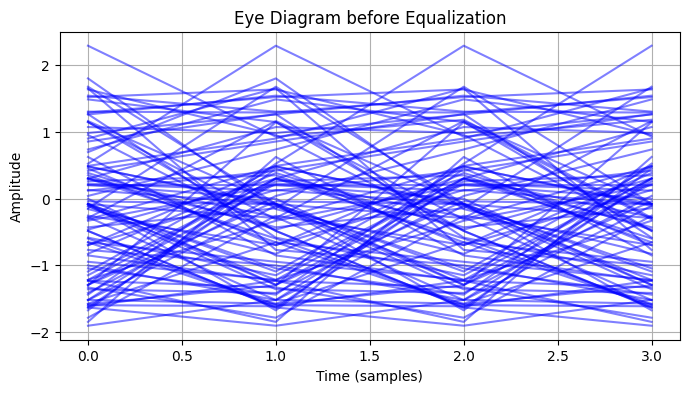

In [14]:
# TODO: Eye diagram before equalization
#digital.plot_eye(received, sps=1)
plot_eye_diagram(received_noisy, sps=1, title='Eye Diagram before Equalization')


The eye-diagram overlays multiple symbol intervals. the "eye" is almost entirely closed, that indicates ISI is present.

## 4. Implement DFE Equalizer

## 2-Tap DFE-Architecture 

![2-Tap DFE Architecture](./Graphics/2_tap_DFE.png)

In [15]:
# TODO: Implement basic DFE equalizer

## 2-Tap DFE implementation
def two_tap_dfe(received, symbols, mu=0.001):
    N = len(received)
    decisions = np.zeros(N)
    dfe_output = np.zeros(N)

    h1 = 0.5    # initial values of h1 and h2 were chosen by trial and error
    h2 = 0.0

    h1_list = []
    h2_list = []
    
    ## Using LMS-Algorithm to minimize error
    for i in range(2, N):
        dfe_out = received[i] - h1 * decisions[i-1] - h2 * decisions[i-2]
        dfe_output[i] = dfe_out

        decisions[i] = 1 if dfe_out >= 0 else -1

        error =  symbols[i] - dfe_out

        h1 += mu * error * decisions[i-1]
        h2 += mu * error * decisions[i-2]

        h1_list.append(h1)
        h2_list.append(h2)

    return dfe_output, decisions, h1_list, h2_list

In [16]:
## Apply the DFE
dfe_output, decisions, h1_track, h2_track = two_tap_dfe(received_noisy, symbols, 0.0001)

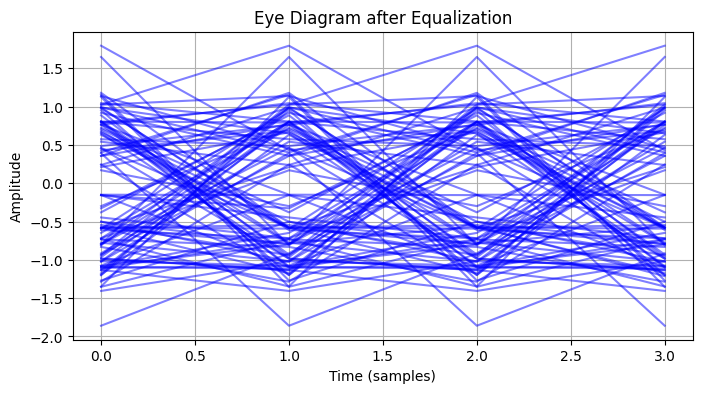

In [17]:
## Plot an eye-diagram of the dfe-output
plot_eye_diagram(dfe_output[2:], sps=1, title='Eye Diagram after Equalization')

The "eye" is almost open that indicates the DFE works, and the bit error rate should be much lower than before equalization

## 5. BER Analysis

In [18]:
# TODO: Compute BER before and after equalization.

# --- Before Equalization ---
# # Make hard decisions on received noisy signal
decisions_before = np.where(received_noisy >= 0, 1, -1)
# calculate the bit error rate before equalization
ber_before = np.mean(decisions_before != symbols)

# calculate the bit error rate after DFE
ber_after = np.mean(decisions != symbols)


# --- Display Results ---
print(f"BER before equalization: {ber_before:.4f}")
print(f"BER after  equalization: {ber_after:.4f}")


BER before equalization: 0.0800
BER after  equalization: 0.0070


## 6. Reflection
- How does DFE mitigate ISI?
- Practical relevance (DSL, LTE, etc.).

## Reflection on the 2-Tap DFE Architecture

 

In our project, we implemented a Decision Feedback Equalizer (DFE) with two feedback taps (h₁ and h₂). This decision was guided by the structure of the simulated intersymbol interference (ISI) channel, which exhibited short postcursor tails.

 

### Why a 2-Tap DFE?

 

- **Simplicity**: The 2-tap DFE design offers a minimalistic structure with low computational complexity, making it suitable for real-time applications and hardware implementation.

- **Efficiency**: With fewer coefficients to train, the DFE converges faster during adaptation with LMS, which is ideal for short training sequences or low-latency systems.

- **Effectiveness**: In our simulated channel with impulse response `h = [0.8, 0.5]`, the first two postcursors captured the majority of the ISI. A 2-tap feedback loop effectively suppressed these interferences.

- **Practical Relevance**: This architecture mirrors many real-world systems, such as USB, HDMI, and short-range DSL links, where ISI from only 1–2 previous bits significantly impacts symbol detection. LTE and 5G do not typically use time domain DFE, because they rely on OFDM. 
 

### Limitations
 

- Does not handle **precursor ISI** — additional feedforward taps would be required.

- Not suitable for **severe or long-duration ISI** channels.

- It does not suppress or reject additive noise (AWGN). In fact, poorly tuned DFE can even amplify the impact of noise, especially if it propagates bad decisions.

- To mitigate the effects of noise usually a matched filter is connected before the DFE.

 

### Conclusion
Cancels postcursor intersymbol interference (ISI) by subtracting the ISI contribution of past detected symbols.

Operates deterministically using previous decisions — not probabilistic noise modeling.

## Sources
- IEEE SOLID-STATE CIRCUITS MAGAZINE fall 2017, The Decision Feedback Analyzer, Behzad Razavi
- Nachrichtentechnik Eine Einführung für alle Studiengänge 8. Auflage, Martin Werner, Springer Viehweg